# Test 09: Scale law на хаотических данных

**Цель:** Проверить, переносится ли scale law из тестов 07-08 (LLM активации) на **хаотические dynamical systems**. Это даёт claim про **universal applicability** для двух статей сразу.

**Гипотезы:**

- **H1 (universal):** тот же закон $a^* \approx c \cdot \sigma_{post}^{-\gamma}$ работает на хаосе с похожим $\gamma \approx 0.5$
- **H2 (domain-specific):** хаос требует другие $\gamma, c$ (но всё равно power law)
- **H3 (no law):** хаотические данные не следуют scale law

**Домены:**

| Domain | Размерность | Природа | Источник |
|---|---|---|---|
| Logistic map | 1D (sequence) | дискретный хаос | $x_{t+1} = r x_t (1 - x_t)$, $r=3.99$ |
| Hénon attractor | 2D | низкоразмерный странный аттрактор | $(x', y') = (1 - 1.4 x^2 + y, 0.3 x)$ |
| Lorenz-96 | 40D | высокоразмерный chaos | $\dot{x}_i = (x_{i+1} - x_{i-2}) x_{i-1} - x_i + F$, $F=8$ |

**Что меняется относительно тестов 07-08:**

1. Данные генерируются программно (не GPT-2 активации)
2. Размерность входа меньше (1, 2, 40 vs 768)
3. SAE архитектура адаптирована: latent_dim = 4× input_dim, K = max(latent_dim/10, 4)
4. Sample size ~5000 (быстрее тренировка)

**Total runs:** 3 domains × 4 input_scales × 5 a-values × 2 seeds = **120 runs**.

**Время на A100:** ~3-4 часа (~20 units).

**Что покажет:**

Если в обоих тестах (08 LLM + 09 chaos) закон с похожим $\gamma$ → **scale law universal across domains**, что значительно усиливает обе статьи.

## 1. Установка и подключение Drive

In [4]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import json
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from scipy.integrate import odeint

from google.colab import drive
drive.mount('/content/drive')

PROTO_DIR = Path('/content/drive/MyDrive/chaos_compressor')
JSONS_DIR = PROTO_DIR / 'jsons'
RESULTS_DIR = PROTO_DIR / 'scale_law_chaos_results'
DATA_DIR = Path('/content/data')

PROTO_DIR.mkdir(exist_ok=True, parents=True)
JSONS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

Mounted at /content/drive


## 2. Генерация хаотических данных

Каждый domain имеет свою динамику. Для SAE нам нужны **фазовые пространства** (snapshots состояний), не временные ряды.

In [5]:
N_SAMPLES = 5000


def generate_logistic(n_samples, r=3.99, seed=42):
    """Логистическая карта: x_{t+1} = r x_t (1 - x_t). Возвращает snapshots (window-based)."""
    rng = np.random.RandomState(seed)
    window = 64
    samples = []
    for i in range(n_samples):
        x0 = rng.uniform(0.01, 0.99)
        seq = [x0]
        for _ in range(window - 1):
            seq.append(r * seq[-1] * (1 - seq[-1]))
        samples.append(seq)
    return np.array(samples, dtype='float32')


def generate_henon(n_samples, a=1.4, b=0.3, seed=42):
    """Исправленная версия Henon: гарантированно на аттракторе + лёгкие пертурбации."""
    rng = np.random.RandomState(seed)
    samples = []

    # Надёжная стартовая точка на аттракторе
    x, y = 0.1, 0.1

    for i in range(n_samples):
        # Burn-in (уже на аттракторе, поэтому короткий)
        for _ in range(50):
            x = 1 - a * x*x + y
            y = b * x

        # Собираем 32 шага → 64-мерный snapshot
        traj = []
        for _ in range(32):
            x = 1 - a * x*x + y
            y = b * x
            traj.extend([float(x), float(y)])

        samples.append(traj)

        # Небольшая пертурбация каждые 5 сэмплов — для разнообразия
        if i % 5 == 0:
            x += rng.uniform(-0.02, 0.02)
            y += rng.uniform(-0.02, 0.02)

    return np.array(samples, dtype='float32')


def generate_lorenz96(n_samples, n_dim=40, F=8.0, dt=0.05, n_steps=100, seed=42):
    """Lorenz-96 (без изменений — он уже стабильный)."""
    rng = np.random.RandomState(seed)

    def rhs(x, t):
        dx = np.zeros_like(x)
        for i in range(len(x)):
            dx[i] = (x[(i + 1) % len(x)] - x[i - 2]) * x[i - 1] - x[i] + F
        return dx

    samples = []
    for i in range(n_samples // 50 + 1):
        x0 = F + 0.01 * rng.randn(n_dim)
        t = np.linspace(0, dt * n_steps, n_steps)
        traj = odeint(rhs, x0, t)
        for j in range(0, n_steps, 2):
            samples.append(traj[j])
            if len(samples) >= n_samples:
                return np.array(samples[:n_samples], dtype='float32')
    return np.array(samples[:n_samples], dtype='float32')


# === Запуск генерации ===
print('Генерация Logistic Map...')
logistic = generate_logistic(N_SAMPLES)
print(f'  shape: {logistic.shape}, range: [{logistic.min():.3f}, {logistic.max():.3f}]')

print('Генерация Henon Attractor...')
henon = generate_henon(N_SAMPLES)
print(f'  shape: {henon.shape}, range: [{henon.min():.3f}, {henon.max():.3f}]')

print('Генерация Lorenz-96 (40D)...')
lorenz = generate_lorenz96(N_SAMPLES)
print(f'  shape: {lorenz.shape}, range: [{lorenz.min():.3f}, {lorenz.max():.3f}]')

Генерация Logistic Map...
  shape: (5000, 64), range: [0.010, 0.998]
Генерация Henon Attractor...
  shape: (5000, 64), range: [-0.128, 1.011]
Генерация Lorenz-96 (40D)...
  shape: (5000, 40), range: [-13.620, 18.230]


In [6]:
# === Нормализация и save ===

def normalize_split(data, seed=42):
    m = data.mean(axis=0, keepdims=True)
    s = data.std(axis=0, keepdims=True) + 1e-8
    norm = ((data - m) / s).astype('float32')
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(norm))
    split = int(len(idx) * 0.8)
    return norm[idx[:split]], norm[idx[split:]]


chaos_domains = {
    'logistic': logistic,
    'henon': henon,
    'lorenz96': lorenz,
}

for name, data in chaos_domains.items():
    x_train, x_test = normalize_split(data)
    np.save(DATA_DIR / f'x_train_chaos_{name}.npy', x_train)
    np.save(DATA_DIR / f'x_test_chaos_{name}.npy', x_test)
    print(f'{name}: train {x_train.shape}, test {x_test.shape}, '
          f'std after norm: {x_train.std():.3f}')

logistic: train (4000, 64), test (1000, 64), std after norm: 1.001
henon: train (4000, 64), test (1000, 64), std after norm: 1.000
lorenz96: train (4000, 40), test (1000, 40), std after norm: 1.001


## 3. Worker-скрипт (адаптирован под chaotic data)

In [7]:
%%writefile /content/scale_law_chaos_worker.py
"""Worker для теста 09 — chaos domains."""
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import json
import argparse
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy import stats as sp_stats


def chaos_activation(x, a=1.0, w=0.5, b=4.0):
    return tf.sin(a * x) + w * tf.tanh(b * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    def call(self, inputs):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask


class ChaosActivation(layers.Layer):
    def __init__(self, a=1.0, w=0.5, b=4.0, **kwargs):
        super().__init__(**kwargs)
        self.a = a; self.w = w; self.b = b
    def call(self, x):
        return chaos_activation(x, self.a, self.w, self.b)


def build_sae(input_dim, latent_dim, k_active, a, w=0.5, b=4.0):
    inp = keras.Input(shape=(input_dim,))
    pre = layers.Dense(latent_dim, name='latent_pre')(inp)
    act = ChaosActivation(a=a, w=w, b=b, name='chaos_act')(pre)
    z = KSparseLayer(k=k_active, name='latent_ksparse')(act)
    enc = keras.Model(inp, z, name='encoder')
    pre_model = keras.Model(inp, pre, name='pre_model')
    decoded = layers.Dense(input_dim, name='decoder')(z)
    ae = keras.Model(inp, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, pre_model


def measure_metrics(ae, enc, pre_model, x_test_raw, input_scale):
    x_scaled = x_test_raw * input_scale
    sigma_input = float(np.std(x_scaled, axis=0).mean())
    pre_acts = pre_model.predict(x_scaled, batch_size=256, verbose=0)
    sigma_post_dense = float(np.std(pre_acts, axis=0).mean())
    latents = enc.predict(x_scaled, batch_size=256, verbose=0)
    nonzero = latents[np.abs(latents) > 1e-10]
    kurt = float(sp_stats.kurtosis(nonzero)) if nonzero.size > 0 else 0.0
    dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
    return {
        'sigma_eff_input': sigma_input,
        'sigma_eff_post_dense': sigma_post_dense,
        'kurtosis': kurt,
        'dead_latents': dead,
    }


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--domain', type=str, required=True)
    parser.add_argument('--input_scale', type=float, required=True)
    parser.add_argument('--a', type=float, required=True)
    parser.add_argument('--seed', type=int, required=True)
    parser.add_argument('--epochs', type=int, default=10)
    parser.add_argument('--batch', type=int, default=128)
    parser.add_argument('--data_dir', type=str, required=True)
    parser.add_argument('--output', type=str, required=True)
    args = parser.parse_args()

    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for g in gpus:
            try: tf.config.experimental.set_memory_growth(g, True)
            except RuntimeError: pass

    x_train_raw = np.load(f'{args.data_dir}/x_train_chaos_{args.domain}.npy')
    x_test_raw = np.load(f'{args.data_dir}/x_test_chaos_{args.domain}.npy')
    INPUT_DIM = x_train_raw.shape[1]
    LATENT_DIM = INPUT_DIM * 4
    K_ACTIVE = max(LATENT_DIM // 10, 4)

    x_train = x_train_raw * args.input_scale
    x_test = x_test_raw * args.input_scale

    np.random.seed(args.seed)
    tf.random.set_seed(args.seed)

    ae, enc, pre_model = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, a=args.a, w=0.5, b=4.0)
    hist = ae.fit(x_train, x_train, epochs=args.epochs, batch_size=args.batch,
                   validation_data=(x_test, x_test), verbose=0)
    val_loss = float(hist.history['val_loss'][-1])

    metrics = measure_metrics(ae, enc, pre_model, x_test_raw, args.input_scale)

    result = {
        'domain': f'chaos_{args.domain}',
        'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
        'input_scale': args.input_scale, 'a': args.a, 'seed': args.seed,
        'val_loss': val_loss, **metrics,
    }
    with open(args.output, 'w') as f:
        json.dump(result, f, default=float)
    print(f'  {args.domain} scale={args.input_scale} a={args.a} '
          f'seed={args.seed} loss={val_loss:.4f} '
          f'σ_post={metrics["sigma_eff_post_dense"]:.3f}', flush=True)


if __name__ == '__main__':
    main()

Writing /content/scale_law_chaos_worker.py


## 4. Конфигурация эксперимента

In [8]:
DOMAINS = ['logistic', 'henon', 'lorenz96']
INPUT_SCALES = [0.5, 1.0, 2.0, 4.0]
A_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0]
SEEDS = [42, 43]
EPOCHS = 10
BATCH = 128

ALL_CONFIGS = []
for domain in DOMAINS:
    for s in INPUT_SCALES:
        for a in A_VALUES:
            for seed in SEEDS:
                ALL_CONFIGS.append((domain, s, a, seed))

print(f'Domains: {DOMAINS}')
print(f'Scales: {INPUT_SCALES}')
print(f'A values: {A_VALUES}')
print(f'Total runs: {len(ALL_CONFIGS)}')

Domains: ['logistic', 'henon', 'lorenz96']
Scales: [0.5, 1.0, 2.0, 4.0]
A values: [0.25, 0.5, 1.0, 2.0, 4.0]
Total runs: 120


## 5. Главный цикл

In [9]:
ts_start = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Start: {ts_start}\n')

completed = 0; skipped = 0; failed = []

for domain, input_scale, a_val, seed in ALL_CONFIGS:
    tag = f'{domain}_s{input_scale}_a{a_val}_seed{seed}'
    output_file = RESULTS_DIR / f'{tag}.json'
    if output_file.exists():
        skipped += 1
        continue
    cmd = [
        'python', '/content/scale_law_chaos_worker.py',
        '--domain', domain,
        '--input_scale', str(input_scale),
        '--a', str(a_val),
        '--seed', str(seed),
        '--epochs', str(EPOCHS),
        '--batch', str(BATCH),
        '--data_dir', str(DATA_DIR),
        '--output', str(output_file),
    ]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=900)
        if result.returncode == 0:
            if result.stdout.strip(): print(result.stdout.strip())
            completed += 1
        else:
            print(f'  [FAILED] {tag}: {result.stderr[-300:]}')
            failed.append(tag)
    except subprocess.TimeoutExpired:
        print(f'  [TIMEOUT] {tag}')
        failed.append(tag)
    except Exception as e:
        print(f'  [ERROR] {tag}: {e}')
        failed.append(tag)

print(f'\nDone: {completed} new, {skipped} skipped, {len(failed)} failed')

Start: 20260505_162751


Done: 0 new, 120 skipped, 0 failed


## 6. Анализ — per-domain scale law

In [10]:
# === Загрузка результатов ===

all_results = []
for jf in sorted(RESULTS_DIR.glob('*.json')):
    with open(jf) as f:
        all_results.append(json.load(f))

print(f'Loaded {len(all_results)} results')
domains_full = sorted({r['domain'] for r in all_results})
print(f'Domains: {domains_full}')

Loaded 120 results
Domains: ['chaos_henon', 'chaos_logistic', 'chaos_lorenz96']


In [11]:
# === Aggregation per (domain, input_scale, a) ===

def aggregate(domain, input_scale, a_val, all_r):
    runs = [r for r in all_r if r['domain'] == domain
             and abs(r['input_scale'] - input_scale) < 1e-6
             and abs(r['a'] - a_val) < 1e-6]
    if not runs: return None
    return {
        'domain': domain, 'input_scale': input_scale, 'a': a_val,
        'val_loss_mean': float(np.mean([r['val_loss'] for r in runs])),
        'sigma_eff_input': float(np.mean([r['sigma_eff_input'] for r in runs])),
        'sigma_eff_post_dense': float(np.mean([r['sigma_eff_post_dense'] for r in runs])),
        'n_runs': len(runs),
    }


best_per_domain_scale = {}
for domain in domains_full:
    domain_results = [r for r in all_results if r['domain'] == domain]
    scales = sorted({r['input_scale'] for r in domain_results})
    a_values = sorted({r['a'] for r in domain_results})
    best_per_domain_scale[domain] = {}
    for s in scales:
        rows = [aggregate(domain, s, a, all_results) for a in a_values]
        rows = [r for r in rows if r is not None]
        if not rows: continue
        best = min(rows, key=lambda r: r['val_loss_mean'])
        best_per_domain_scale[domain][s] = best

for domain in domains_full:
    print(f'\n=== {domain} ===')
    print(f'  {"scale":>8} {"a*":>6} {"loss":>10} {"σ_post":>10}')
    for s, d in sorted(best_per_domain_scale[domain].items()):
        print(f'  {s:>8.2f} {d["a"]:>6.2f} {d["val_loss_mean"]:>10.4f} '
              f'{d["sigma_eff_post_dense"]:>10.3f}')


=== chaos_henon ===
     scale     a*       loss     σ_post
      0.50   2.00     0.0000      0.043
      1.00   2.00     0.0002      0.374
      2.00   2.00     0.0000      1.046
      4.00   1.00     0.0000      2.118

=== chaos_logistic ===
     scale     a*       loss     σ_post
      0.50   0.50     0.0649      0.280
      1.00   0.50     0.2639      0.794
      2.00   0.25     1.2279      2.423
      4.00   0.25     7.8988      3.236

=== chaos_lorenz96 ===
     scale     a*       loss     σ_post
      0.50   1.00     0.0509      0.184
      1.00   0.50     0.2175      0.668
      2.00   0.25     1.1890      2.354
      4.00   0.25     7.4435      3.640


In [12]:
# === Per-domain log-log fits ===

def loglog_fit(x_values, y_values):
    x_arr = np.array(x_values, dtype=float)
    y_arr = np.array(y_values, dtype=float)
    valid = (x_arr > 0) & (y_arr > 0)
    if valid.sum() < 3:
        return None, None, None
    log_x = np.log(x_arr[valid])
    log_y = np.log(y_arr[valid])
    if np.std(log_x) < 1e-10 or np.std(log_y) < 1e-10:
        return None, None, None
    try:
        slope, intercept, r_value, _, _ = sp_stats.linregress(log_x, log_y)
    except ValueError:
        return None, None, None
    return -slope, np.exp(intercept), r_value ** 2


domain_fits = {}
for domain in domains_full:
    bps = best_per_domain_scale.get(domain, {})
    x_vals = [d['sigma_eff_post_dense'] for s, d in sorted(bps.items())]
    y_vals = [d['a'] for s, d in sorted(bps.items())]
    gamma, c, r2 = loglog_fit(x_vals, y_vals)
    domain_fits[domain] = {
        'gamma': gamma, 'c': c, 'r_squared': r2,
        'n_points': len(x_vals), 'x_values': x_vals, 'y_values': y_vals,
    }

print('\nPer-domain scale law fits на хаотических данных:\n')
print(f'{"Domain":<25} {"N":>4} {"γ":>8} {"c":>8} {"R²":>8}')
print('-' * 60)
for domain in domains_full:
    f = domain_fits[domain]
    if f['gamma'] is None:
        print(f'{domain:<25} insufficient data')
        continue
    print(f'{domain:<25} {f["n_points"]:>4} {f["gamma"]:>+8.3f} '
          f'{f["c"]:>8.3f} {f["r_squared"]:>8.3f}')


Per-domain scale law fits на хаотических данных:

Domain                       N        γ        c       R²
------------------------------------------------------------
chaos_henon                  4   +0.127    1.513    0.387
chaos_logistic               4   +0.328    0.370    0.844
chaos_lorenz96               4   +0.489    0.423    0.981


## 7. Сравнение с LLM-доменом из тестов 07-08

Универсальность закона — есть ли совпадение $\gamma$ между chaos и LLM?

In [13]:
# === Загрузка LLM результатов из тестов 07-08 ===

llm_results = []
results_07_dir = PROTO_DIR / 'scale_law_results'
results_08_dir = PROTO_DIR / 'scale_law_completion_results'

for d in [results_07_dir, results_08_dir]:
    if d.exists():
        for jf in sorted(d.glob('*.json')):
            with open(jf) as f:
                r = json.load(f)
                if 'domain' not in r:
                    r['domain'] = 'gpt2_l6'  # тест 07 default
                llm_results.append(r)

print(f'LLM results loaded: {len(llm_results)}')
llm_domains = sorted({r['domain'] for r in llm_results})
print(f'LLM domains: {llm_domains}')

# === Combine с chaos results ===

combined = llm_results + all_results
combined_domains = sorted({r['domain'] for r in combined})
print(f'\nAll domains in combined analysis: {combined_domains}')

LLM results loaded: 188
LLM domains: ['gpt2_l3', 'gpt2_l6', 'gpt2_l9', 'pythia160m_l6']

All domains in combined analysis: ['chaos_henon', 'chaos_logistic', 'chaos_lorenz96', 'gpt2_l3', 'gpt2_l6', 'gpt2_l9', 'pythia160m_l6']


In [14]:
# === Per-domain best a* для combined results ===

def best_per_domain_scale_func(results_list):
    out = {}
    domains_x = sorted({r['domain'] for r in results_list})
    for domain in domains_x:
        domain_r = [r for r in results_list if r['domain'] == domain]
        scales = sorted({r['input_scale'] for r in domain_r})
        a_values = sorted({r['a'] for r in domain_r})
        out[domain] = {}
        for s in scales:
            rows = []
            for a in a_values:
                runs = [r for r in domain_r if abs(r['input_scale'] - s) < 1e-6
                          and abs(r['a'] - a) < 1e-6]
                if runs:
                    rows.append({
                        'a': a,
                        'val_loss_mean': float(np.mean([r['val_loss'] for r in runs])),
                        'sigma_eff_post_dense': float(np.mean([r['sigma_eff_post_dense'] for r in runs])),
                    })
            if rows:
                out[domain][s] = min(rows, key=lambda r: r['val_loss_mean'])
    return out


combined_best = best_per_domain_scale_func(combined)

# === Combined fit ===

all_combined_x = []; all_combined_y = []; all_combined_dom = []
for domain, scales_dict in combined_best.items():
    for s, d in sorted(scales_dict.items()):
        all_combined_x.append(d['sigma_eff_post_dense'])
        all_combined_y.append(d['a'])
        all_combined_dom.append(domain)

unified_gamma, unified_c, unified_r2 = loglog_fit(all_combined_x, all_combined_y)

print(f'Combined unified fit (LLM + chaos, {len(all_combined_x)} points):')
if unified_gamma is not None:
    print(f'  a* = {unified_c:.3f} · σ_post^({-unified_gamma:+.3f})')
    print(f'  R² = {unified_r2:.3f}')

# === Сравнение γ ===

all_fits = {}
for domain in combined_best:
    bps = combined_best[domain]
    x_vals = [d['sigma_eff_post_dense'] for s, d in sorted(bps.items())]
    y_vals = [d['a'] for s, d in sorted(bps.items())]
    gamma, c, r2 = loglog_fit(x_vals, y_vals)
    if gamma is not None:
        all_fits[domain] = (gamma, c, r2, len(x_vals))

print('\n=== Per-domain γ (LLM + chaos): ===')
print(f'{"Domain":<25} {"N":>4} {"γ":>8} {"R²":>8}')
print('-' * 50)
for domain, (g, c, r2, n) in sorted(all_fits.items()):
    domain_type = 'CHAOS' if domain.startswith('chaos_') else 'LLM'
    print(f'{domain:<25} {n:>4} {g:>+8.3f} {r2:>8.3f}  [{domain_type}]')

# Type-level statistics
llm_gammas = [g for d, (g, _, _, _) in all_fits.items() if not d.startswith('chaos_')]
chaos_gammas = [g for d, (g, _, _, _) in all_fits.items() if d.startswith('chaos_')]

print()
if llm_gammas:
    print(f'LLM γ:   mean = {np.mean(llm_gammas):+.3f}, std = {np.std(llm_gammas):.3f}')
if chaos_gammas:
    print(f'CHAOS γ: mean = {np.mean(chaos_gammas):+.3f}, std = {np.std(chaos_gammas):.3f}')

if llm_gammas and chaos_gammas:
    delta = abs(np.mean(llm_gammas) - np.mean(chaos_gammas))
    print(f'\nΔγ (LLM vs CHAOS) = {delta:.3f}')
    if delta < 0.15:
        print('✅ Universal scale law (γ совпадают в пределах 0.15)')
    else:
        print('⚠ Domain-specific law (γ существенно различаются)')

Combined unified fit (LLM + chaos, 28 points):
  a* = 0.336 · σ_post^(-0.544)
  R² = 0.585

=== Per-domain γ (LLM + chaos): ===
Domain                       N        γ       R²
--------------------------------------------------
chaos_henon                  4   +0.127    0.387  [CHAOS]
chaos_logistic               4   +0.328    0.844  [CHAOS]
chaos_lorenz96               4   +0.489    0.981  [CHAOS]
gpt2_l3                      3   +0.747    0.988  [LLM]
gpt2_l6                      7   +0.644    0.973  [LLM]
gpt2_l9                      3   +0.744    1.000  [LLM]
pythia160m_l6                3   +0.519    0.959  [LLM]

LLM γ:   mean = +0.663, std = 0.093
CHAOS γ: mean = +0.315, std = 0.148

Δγ (LLM vs CHAOS) = 0.349
⚠ Domain-specific law (γ существенно различаются)


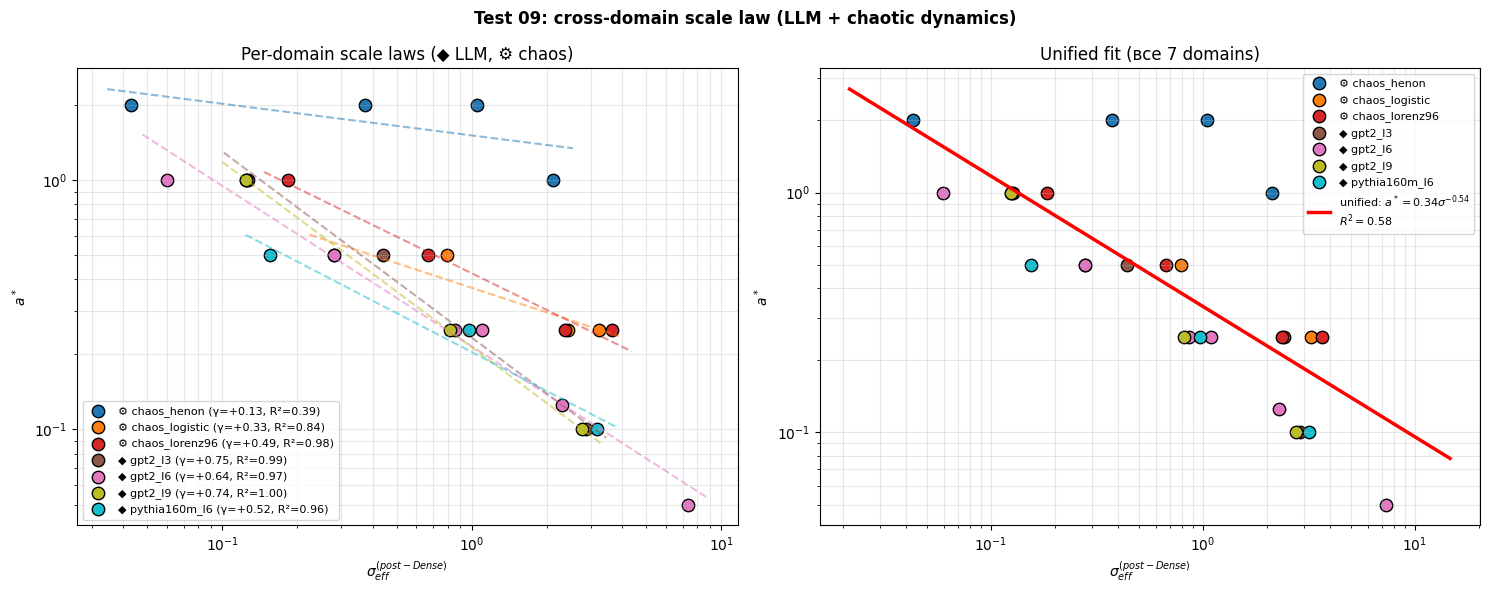

In [15]:
# === Визуализация: cross-domain comparison ===

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Левая: per-domain points + individual fits
ax = axes[0]
domain_colors = {}
all_doms = sorted(all_fits.keys())
colors_arr = plt.cm.tab10(np.linspace(0, 1, len(all_doms)))
for d, c in zip(all_doms, colors_arr):
    domain_colors[d] = c

for domain in all_doms:
    if domain not in all_fits: continue
    bps = combined_best[domain]
    x = np.array([d['sigma_eff_post_dense'] for s, d in sorted(bps.items())])
    y = np.array([d['a'] for s, d in sorted(bps.items())])
    gamma, c, r2, _ = all_fits[domain]
    color = domain_colors[domain]
    domain_type = '⚙' if domain.startswith('chaos_') else '◆'
    ax.scatter(x, y, s=80, color=color, edgecolor='black',
                label=f'{domain_type} {domain} (γ={gamma:+.2f}, R²={r2:.2f})')
    if x.max() > x.min():
        x_fit = np.logspace(np.log10(x.min() * 0.8), np.log10(x.max() * 1.2), 50)
        y_fit = c * x_fit ** (-gamma)
        ax.plot(x_fit, y_fit, '--', color=color, alpha=0.5)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\sigma_{eff}^{(post-Dense)}$'); ax.set_ylabel(r'$a^*$')
ax.set_title('Per-domain scale laws (◆ LLM, ⚙ chaos)')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Правая: unified fit
ax = axes[1]
for domain in all_doms:
    points = [(x, y) for x, y, d in zip(all_combined_x, all_combined_y, all_combined_dom)
              if d == domain]
    if not points: continue
    xs, ys = zip(*points)
    color = domain_colors[domain]
    domain_type = '⚙' if domain.startswith('chaos_') else '◆'
    ax.scatter(xs, ys, s=80, color=color, edgecolor='black',
                label=f'{domain_type} {domain}')

if unified_gamma is not None:
    x_arr = np.array(all_combined_x); valid = (x_arr > 0)
    x_fit = np.logspace(np.log10(x_arr[valid].min() * 0.5),
                          np.log10(x_arr[valid].max() * 2), 100)
    y_fit = unified_c * x_fit ** (-unified_gamma)
    ax.plot(x_fit, y_fit, '-', color='red', linewidth=2.5,
             label=f'unified: $a^* = {unified_c:.2f} \\sigma^{{{-unified_gamma:+.2f}}}$\n$R^2 = {unified_r2:.2f}$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\sigma_{eff}^{(post-Dense)}$'); ax.set_ylabel(r'$a^*$')
ax.set_title(f'Unified fit (все {len(all_doms)} domains)')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Test 09: cross-domain scale law (LLM + chaotic dynamics)',
              fontweight='bold')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'scale_law_chaos_unified.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Финальный вердикт

In [16]:
verdict = {
    'n_chaos_domains': len([d for d in all_fits if d.startswith('chaos_')]),
    'n_llm_domains': len([d for d in all_fits if not d.startswith('chaos_')]),
    'unified_gamma': float(unified_gamma) if unified_gamma is not None else None,
    'unified_c': float(unified_c) if unified_c is not None else None,
    'unified_r2': float(unified_r2) if unified_r2 is not None else None,
}

if llm_gammas and chaos_gammas:
    delta = abs(np.mean(llm_gammas) - np.mean(chaos_gammas))
    verdict['delta_gamma_llm_vs_chaos'] = float(delta)
    verdict['llm_gamma_mean'] = float(np.mean(llm_gammas))
    verdict['chaos_gamma_mean'] = float(np.mean(chaos_gammas))
    if delta < 0.15 and unified_r2 is not None and unified_r2 > 0.85:
        verdict['status'] = 'UNIVERSAL_SCALE_LAW'
    elif delta < 0.30:
        verdict['status'] = 'WEAKLY_UNIVERSAL'
    else:
        verdict['status'] = 'DOMAIN_SPECIFIC'

print('=== Финальный вердикт ===')
print(f'Status: {verdict.get("status", "INSUFFICIENT_DATA")}')
print(f'LLM γ mean: {verdict.get("llm_gamma_mean", "-")}')
print(f'Chaos γ mean: {verdict.get("chaos_gamma_mean", "-")}')
print(f'Δγ: {verdict.get("delta_gamma_llm_vs_chaos", "-")}')
print(f'Unified R²: {verdict.get("unified_r2", "-")}')

print()
if verdict.get('status') == 'UNIVERSAL_SCALE_LAW':
    print('✅ Закон универсален: один и тот же γ работает на LLM и chaos')
    print('   Это сильный supporting result для обеих статей')
elif verdict.get('status') == 'WEAKLY_UNIVERSAL':
    print('🟡 Закон частично переносим: γ близки, но не точно совпадают')
    print('   Подходит как preliminary observation в обеих статьях')
elif verdict.get('status') == 'DOMAIN_SPECIFIC':
    print('⚠ Закон domain-specific: γ существенно различается')
    print('   Каждая статья получает свой scale law')

=== Финальный вердикт ===
Status: DOMAIN_SPECIFIC
LLM γ mean: 0.6634289109945056
Chaos γ mean: 0.3146718003724415
Δγ: 0.3487571106220641
Unified R²: 0.5846323006483634

⚠ Закон domain-specific: γ существенно различается
   Каждая статья получает свой scale law


## 9. Сохранение результатов

In [17]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'scale_law_chaos_domains',
    'timestamp': ts,
    'config': {
        'domains': DOMAINS,
        'input_scales': INPUT_SCALES,
        'a_values': A_VALUES,
        'seeds': SEEDS,
        'epochs': EPOCHS,
        'n_samples': N_SAMPLES,
    },
    'chaos_domain_fits': {d: {k: v for k, v in f.items()
                                if k not in ('x_values', 'y_values')}
                          for d, f in domain_fits.items() if f['gamma'] is not None},
    'all_domain_fits': {d: {'gamma': float(g), 'c': float(c), 'r_squared': float(r2),
                              'n_points': n}
                         for d, (g, c, r2, n) in all_fits.items()},
    'verdict': verdict,
}
out_file = JSONS_DIR / f'scale_law_chaos_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
out_file

PosixPath('/content/drive/MyDrive/chaos_compressor/jsons/scale_law_chaos_20260505_162814.json')